In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import argparse
import tensorflow as tf
import random
from tensorflow.keras import Model, layers
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
from collections import defaultdict
from pathlib import Path
import os
import matplotlib.pyplot as plt

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

2026-06-21 13:23:26.253808: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782048206.278776     945 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782048206.286553     945 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782048206.308236     945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782048206.308258     945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782048206.308261     945 computation_placer.cc:177] computation placer alr

# IMAGE PREPROCESSING

In [2]:
img_folder_dir=["/kaggle/input/datasets/afqwe0/clotheslabelled/Himesh/Dolphin shorts",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Himesh/Jacket",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Himesh/cardigan",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Himesh/cowl neck top",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Himesh/denim shorts (jorts)",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Himesh/fit-and-flare dress",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Himesh/skirt",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Himesh/turtle neck",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Mahesh/Dhaka Topi",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Mahesh/Formal Pants Shirt Set",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Mahesh/Loafers",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Mahesh/Sari",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Mahesh/men_suits_western_coatpant",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Pratik/Blazer",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Pratik/Hoodie",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Pratik/Polo",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Pratik/Sneakers",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Pratik/Sweater",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Pratik/T-Shirt",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Pratik/Trousers",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Sworup/Baggy Pants",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Sworup/Caps",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Sworup/Jeans Pants",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Sworup/One Piece",
               "/kaggle/input/datasets/afqwe0/clotheslabelled/Sworup/Sweat Shirt"]

In [3]:
clothing_similarity_map = {
    # Headwear Cluster
    "Dhaka Topi": ["Caps","men_suits_western_coatpant","Formal Pants Shirt Set"],
    "Caps": ["Dhaka Topi","men_suits_western_coatpant","Formal Pants Shirt Set"],
    
    # Footwear Cluster
    "Sneakers": ["Loafers","Formal Pants Shirt Set","men_suits_western_coatpant"],
    "Loafers": ["Sneakers","Formal Pants Shirt Set","men_suits_western_coatpant"],
    
    # Outerwear & Heavy Tops
    "Jacket": ["Blazer", "cardigan", "Hoodie", "Sweat Shirt"],
    "Blazer": ["Jacket", "men_suits_western_coatpant", "Formal Pants Shirt Set"],
    "cardigan": ["Sweater", "Jacket", "Sweat Shirt", "turtle neck"],
    "Sweater": ["cardigan", "Sweat Shirt", "Hoodie", "turtle neck"],
    "Hoodie": ["Sweat Shirt", "Sweater", "Jacket"],
    "Sweat Shirt": ["Hoodie", "Sweater", "T-Shirt", "cardigan"],
    "turtle neck": ["Sweater", "cardigan", "cowl neck top", "T-Shirt"],
    
    # Light Tops
    "T-Shirt": ["Polo", "cowl neck top", "Sweat Shirt"],
    "Polo": ["T-Shirt", "cowl neck top"],
    "cowl neck top": ["T-Shirt", "Polo", "turtle neck"],
    
    # Full Body / Traditional Suits & Dresses
    "men_suits_western_coatpant": ["Formal Pants Shirt Set", "Blazer", "Trousers"],
    "Formal Pants Shirt Set": ["men_suits_western_coatpant", "Trousers", "Blazer"],
    "Sari": ["One Piece", "fit-and-flare dress"],
    "One Piece": ["fit-and-flare dress", "Sari", "skirt"],
    "fit-and-flare dress": ["One Piece", "skirt", "Sari"],
    
    # Long Lower Body
    "Trousers": ["Jeans Pants", "Baggy Pants", "Formal Pants Shirt Set"],
    "Jeans Pants": ["Baggy Pants", "Trousers", "denim shorts (jorts)"],
    "Baggy Pants": ["Jeans Pants", "Trousers"],
    
    # Short Lower Body
    "Dolphin shorts": ["denim shorts (jorts)", "skirt"],
    "denim shorts (jorts)": ["Dolphin shorts", "skirt", "Jeans Pants"],
    "skirt": ["Dolphin shorts", "denim shorts (jorts)", "fit-and-flare dress"]
}

In [4]:
labels_dir="/kaggle/input/datasets/afqwe0/clotheslabelled/Labels"
OUTPUT_DIR="/kaggle/working/"
CLASS_NAMES = {
    0: 'T-Shirt',
    1: 'Trousers',
    2: 'Blazer',
    3: 'Hoodie',
    4: 'Sneakers',
    5: 'Dolphin shorts',
    6: 'denim shorts (jorts)',
    7: 'fit-and-flare dress',
    8: 'Jacket',
    9: 'skirt',
    10: 'men_suits_western_coatpant',
    11: 'Loafers',
    12: 'Formal Pants Shirt Set',
    13: 'Dhaka Topi',
    14: 'Sari',
    15: 'Baggy Pants',
    16: 'Jeans Pants',
    17: 'One Piece',
    18: 'Sweat Shirt',
    19: 'Caps',
    20: 'cardigan',
    21: 'cowl neck top',
    22: 'turtle neck',
    23: 'Polo',
    24: 'Sweater'
}

os.makedirs(f'{OUTPUT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/embeddings',  exist_ok=True)


In [25]:
# Model
IMG_SIZE        = 224
EMBED_DIM       = 512
MARGIN          = 0.3    # triplet loss margin
LAMBDA_TRIPLET  = 0.7    # loss weight for triplet
LAMBDA_RECON    = 0.3    # loss weight for reconstruction

# Training
BATCH_SIZE      = 32
EPOCHS          = 40
STEPS_PER_EPOCH = 200
VAL_STEPS       = 40
TEST_STEPS=40
LR_INIT         = 1e-4

In [6]:
def parse_yolo_line(line):
    parts=line.strip().split()
    return int(parts[0]),float(parts[1]),float(parts[2]),float(parts[3]),float(parts[4])

In [7]:
def load_crops_multiple_dirs(images_dir_list,labels_dirs):
    #this is to return image for the decoder later on 
    class_to_paths=defaultdict(list)
    for label_file in Path(labels_dirs).glob('*.txt'):
        img_path=None
        for ext in ('.jpg', '.jpeg', '.png', '.webp'):
            for img_dir in images_dir_list:
                candidate=Path(img_dir)/(label_file.stem+ext)
                if candidate.exists():
                    img_path=str(candidate)
                    break
            if img_path is not None:
                break
        if img_path is None:
            continue
        with open(label_file) as f:
            for line in f:
                if not line.strip():
                    continue
                cid,cx,cy,bw,bh=parse_yolo_line(line)
                class_to_paths[cid].append(f'{img_path}|{cx},{cy},{bw},{bh}')
    return  {k:v for k, v in class_to_paths.items() if len(v)>=2}
    

In [8]:
def split_dataset(class_to_paths, train_ratio=0.7, val_ratio=0.15, seed=42):
    """
    Splits each class independently so every class appears in all three sets.
    test_ratio is implied: 1 - train_ratio - val_ratio = 0.15
    """
    random.seed(seed)
    np.random.seed(seed)

    train_data, val_data, test_data = {}, {}, {}
    skipped = []

    for cid, records in class_to_paths.items():
        records = records.copy()
        random.shuffle(records)
        n = len(records)

        if n < 3:
            train_data[cid] = records   # too few — train only
            skipped.append((cid, n))
            continue

        n_train = max(1, int(n * train_ratio))
        n_val   = max(1, int(n * val_ratio))
        n_test  = n - n_train - n_val
        if n_test < 1:          # edge case: give test at least 1
            n_val -= 1
            n_test = 1

        train_data[cid] = records[:n_train]
        val_data[cid]   = records[n_train : n_train + n_val]
        test_data[cid]  = records[n_train + n_val :]

    # ── Report ──
    n_tr  = sum(len(v) for v in train_data.values())
    n_va  = sum(len(v) for v in val_data.values())
    n_te  = sum(len(v) for v in test_data.values())
    total = n_tr + n_va + n_te

    print(f"Split summary  (seed={seed})")
    print(f"  Train : {n_tr:5d}  ({100*n_tr/total:.1f}%)")
    print(f"  Val   : {n_va:5d}  ({100*n_va/total:.1f}%)")
    print(f"  Test  : {n_te:5d}  ({100*n_te/total:.1f}%)")
    if skipped:
        print(f"\n  ⚠ Classes with < 3 samples (train only): "
              f"{[(CLASS_NAMES.get(c,c), n) for c,n in skipped]}")

    print(f"\n  {'Class':<14} {'Train':>6} {'Val':>6} {'Test':>6}")
    print(f"  {'-'*36}")
    for cid in sorted(class_to_paths.keys()):
        name = CLASS_NAMES.get(cid, f'cls_{cid}')
        tr = len(train_data.get(cid, []))
        va = len(val_data.get(cid, []))
        te = len(test_data.get(cid, []))
        print(f"  {name:<14} {tr:>6} {va:>6} {te:>6}")

    return train_data, val_data, test_data


In [9]:
def decode_crop(record):
    #this would  actually take the info about all the labels and crop it according to it
    # first we read the label
    if isinstance(record, list):
        record = record[0]
    path_part,dim_part=record.split('|')
    cx,cy,bw,bh=[float(v) for v in dim_part.split(',')]
    #reading images and normalising it with the range
    raw=tf.io.read_file(path_part)
    img=tf.image.decode_image(raw,channels=3,expand_animations=False)
    img=tf.cast(img,tf.float32)/255.0
    #converting dimension to image  so tf need left and right box so it  can crop the images
    x1 = tf.maximum(cx - bw / 2, 0.0)
    y1 = tf.maximum(cy - bh / 2, 0.0)
    x2 = tf.minimum(cx + bw / 2, 1.0)
    y2 = tf.minimum(cy + bh / 2, 1.0)
    #now cropping and resizing
    boxes=tf.expand_dims([y1, x1, y2, x2], 0) #crops expects batch
    img_4d=tf.expand_dims(img,0)
    crop=tf.image.crop_and_resize(
        img_4d,boxes,box_indices=tf.constant([0]),
    crop_size=[IMG_SIZE, IMG_SIZE],
    )[0]
    return crop
    

In [10]:
def blur(img):
    kernel = tf.ones((3,3,3,1)) / 9.0
    img = tf.expand_dims(img, 0)
    img = tf.nn.depthwise_conv2d(img, kernel, strides=[1,1,1,1], padding='SAME')
    return img[0]

In [11]:
def augment(img):
    # --- 1. Geometric Augmentations ---
    # Randomly flip horizontally
    img = tf.image.random_flip_left_right(img)
    
    # Random rotations (0, 90, 180, 270 degrees)
    img = tf.image.rot90(img, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    
    # --- 2. Lighting & Color Augmentations ---
    # Simulate different environments (indoor/outdoor/daylight)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
    img = tf.image.random_hue(img, max_delta=0.05)
    
    # --- 3. Noise & Blur (Simulating low-quality smartphone cameras) ---
    # Add Gaussian-style noise to mimic low-light sensor grain
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.03, dtype=tf.float32)
    img = tf.add(img, noise)
    
    # Apply a gentle Gaussian blur to simulate out-of-focus or shaky photos
    # tfa.image.gaussian_filter2d requires standard tensor input
    img = blur(img)
    
    # --- 4. Final Cleanup ---
    # Ensure pixel values stay in the valid [0, 1] range after adding noise
    return tf.clip_by_value(img, 0.0, 1.0)

In [12]:
class TripletGenerator(tf.keras.utils.Sequence):
    def __init__(self, class_to_paths, batch_size, steps_for_epoch, augment_images=True, similarity_map=None):
        self.c2p = class_to_paths
        self.classes = sorted(class_to_paths.keys())
        self.batch = batch_size
        self.steps = steps_for_epoch
        self.augment = augment_images
        # A dictionary mapping a class to its visually similar competitor classes
        self.similarity_map = similarity_map 

    def __len__(self):
        return self.steps

    def _load(self, record, do_aug=False):
        img = decode_crop(record).numpy()
        if do_aug:
            img = augment(tf.constant(img)).numpy()
        return img

    def __getitem__(self, _):
        anchors, positives, negatives = [], [], []
        
        for _ in range(self.batch):
            anc_class = random.choice(self.classes)
            
            # Smart Negative Selection Logic
            if self.similarity_map and anc_class in self.similarity_map:
                # Force the negative to be chosen from visually similar classes
                neg_class = random.choice(self.similarity_map[anc_class])
            else:
                # Fallback to completely random if no similarity map is provided
                neg_class = random.choice([c for c in self.classes if c != anc_class])
            
            anc_r, pos_r = random.sample(self.c2p[anc_class], 2)
            neg_r = random.sample(self.c2p[neg_class], 1)
            
            anchors.append(self._load(anc_r, self.augment))
            positives.append(self._load(pos_r, self.augment))
            negatives.append(self._load(neg_r, False))
        
        a = np.stack(anchors).astype(np.float32)
        p = np.stack(positives).astype(np.float32)
        n = np.stack(negatives).astype(np.float32)
        
        return {'anchor': a, 'positive': p, 'negative': n}, np.zeros(self.batch)

In [13]:
print('Scanning dataset across multiple directories...')
CLASS_TO_PATHS = load_crops_multiple_dirs(img_folder_dir, labels_dir)

# 3. Calculate and print the results
n_classes      = len(CLASS_TO_PATHS)
total_samples  = sum(len(v) for v in CLASS_TO_PATHS.values())

print(f'  Classes found : {n_classes}')
print(f'  Total crops   : {total_samples}')
print('\nSamples per class:')

# 4. Display the breakdown per class
for cid, paths in sorted(CLASS_TO_PATHS.items()):
    # Using your CLASS_NAMES dictionary from earlier to get the text label
    class_name = CLASS_NAMES.get(cid, "Unknown")
    print(f'  [{cid:2d}] {class_name:25s}  {len(paths):5d} images')

Scanning dataset across multiple directories...
  Classes found : 25
  Total crops   : 4767

Samples per class:
  [ 0] T-Shirt                      111 images
  [ 1] Trousers                     102 images
  [ 2] Blazer                        98 images
  [ 3] Hoodie                       222 images
  [ 4] Sneakers                     145 images
  [ 5] Dolphin shorts               124 images
  [ 6] denim shorts (jorts)         169 images
  [ 7] fit-and-flare dress          228 images
  [ 8] Jacket                        61 images
  [ 9] skirt                        228 images
  [10] men_suits_western_coatpant    811 images
  [11] Loafers                      589 images
  [12] Formal Pants Shirt Set       339 images
  [13] Dhaka Topi                   186 images
  [14] Sari                         143 images
  [15] Baggy Pants                  105 images
  [16] Jeans Pants                  133 images
  [17] One Piece                    112 images
  [18] Sweat Shirt                  134 i

In [14]:
train_data, val_data, test_data = split_dataset(
    CLASS_TO_PATHS,
    train_ratio=0.70,
    val_ratio=0.15,
    # test_ratio = 0.15 implied
)

Split summary  (seed=42)
  Train :  3325  (69.8%)
  Val   :   703  (14.7%)
  Test  :   739  (15.5%)

  Class           Train    Val   Test
  ------------------------------------
  T-Shirt            77     16     18
  Trousers           71     15     16
  Blazer             68     14     16
  Hoodie            155     33     34
  Sneakers          101     21     23
  Dolphin shorts     86     18     20
  denim shorts (jorts)    118     25     26
  fit-and-flare dress    159     34     35
  Jacket             42      9     10
  skirt             159     34     35
  men_suits_western_coatpant    567    121    123
  Loafers           412     88     89
  Formal Pants Shirt Set    237     50     52
  Dhaka Topi        130     27     29
  Sari              100     21     22
  Baggy Pants        73     15     17
  Jeans Pants        93     19     21
  One Piece          78     16     18
  Sweat Shirt        93     20     21
  Caps               76     16     17
  cardigan           98     21 

I0000 00:00:1782048229.905344     945 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782048229.910854     945 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


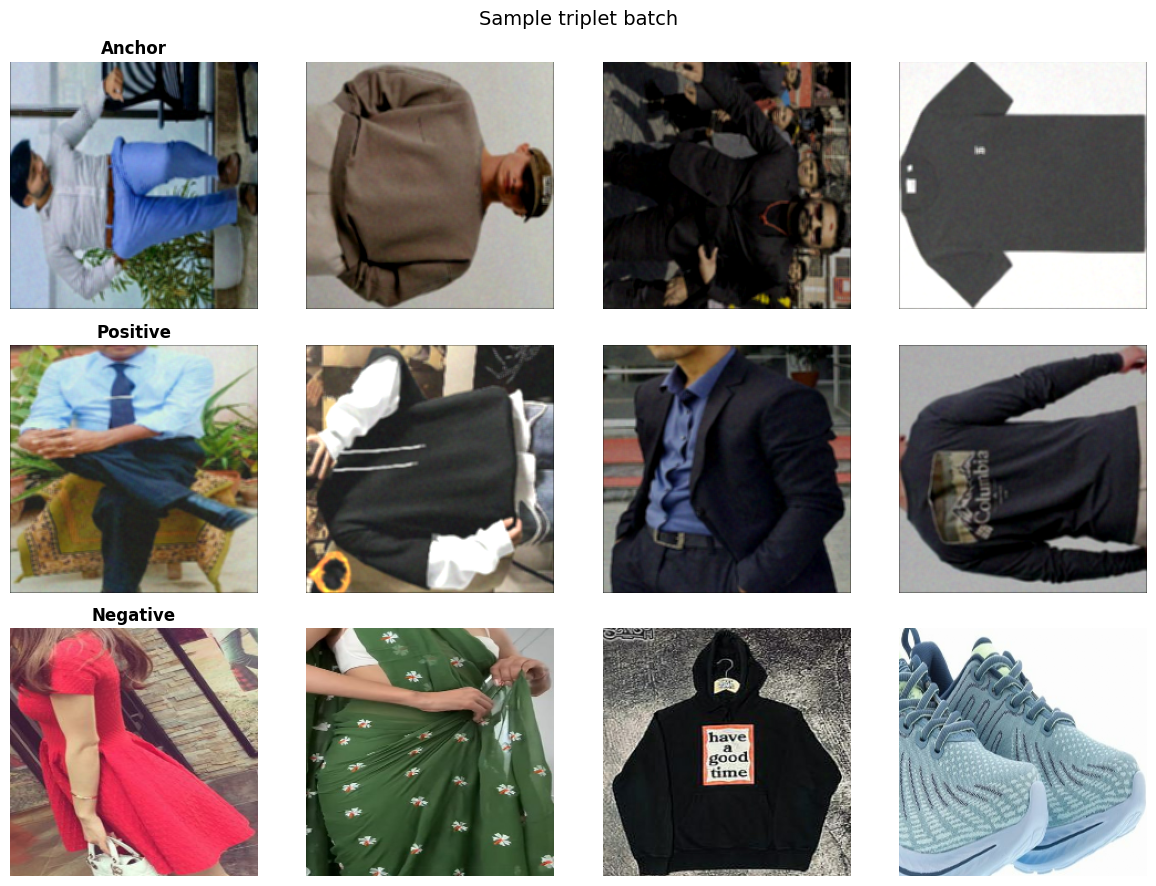

In [15]:
#visualisation of one triplet
gen = TripletGenerator(CLASS_TO_PATHS, batch_size=4,
                       steps_for_epoch=1, augment_images=True,similarity_map=clothing_similarity_map)
sample_inputs, _ = gen[0]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
titles = ['Anchor', 'Positive', 'Negative']
for row, (key, title) in enumerate(zip(['anchor', 'positive', 'negative'], titles)):
    for col in range(4):
        axes[row, col].imshow(sample_inputs[key][col])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(title, fontsize=12, fontweight='bold')
plt.suptitle('Sample triplet batch', fontsize=14)
plt.tight_layout()
plt.show()

# MODELS

In [16]:
#this is single unit of a decoder
def upsample_block(x,filters,name):
    x = layers.Conv2DTranspose(
        filters, kernel_size=4, strides=2, padding='same',
        use_bias=False, name=f'{name}_deconv')(x)
    x = layers.BatchNormalization(name=f'{name}_bn1')(x)
    x = layers.ReLU(name=f'{name}_relu1')(x)
    x = layers.Conv2D(
        filters, kernel_size=3, padding='same',
        use_bias=False, name=f'{name}_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_bn2')(x)
    x = layers.ReLU(name=f'{name}_relu2')(x)
    return x

In [17]:
#entire decoder
def build_decoder(feat, prefix="dec"):
    x = upsample_block(feat, 512, f'{prefix}_up1')   # 14×14
    x = upsample_block(x,   256, f'{prefix}_up2')    # 28×28
    x = upsample_block(x,   128, f'{prefix}_up3')    # 56×56
    x = upsample_block(x,    64, f'{prefix}_up4')    # 112×112
    x = upsample_block(x,    32, f'{prefix}_up5')    # 224×224
    x = layers.Conv2D(3, kernel_size=1, padding='same',
                      activation='sigmoid', name=f'{prefix}_out')(x)
    return x
    

In [18]:
#actual head of the model that gives the location
def build_embedding_head(feat,embed_dim=512,prefix="embed"):
    x = layers.GlobalAveragePooling2D(name=f'{prefix}_gap')(feat)
    x = layers.Dense(embed_dim, use_bias=False, name=f'{prefix}_fc')(x)
    x = layers.BatchNormalization(name=f'{prefix}_bn')(x)
    x = layers.Lambda(
        lambda v: tf.math.l2_normalize(v, axis=1),
        name=f'{prefix}_l2')(x)
    return x
    

In [19]:
#combining full model
def build_full_model(embed_dim=512, img_size=224):
    inp_shape=(IMG_SIZE,IMG_SIZE,3)
    anchor=layers.Input(inp_shape,name='anchor')
    positive=layers.Input(inp_shape,name='positive')
    negative=layers.Input(inp_shape,name='negative')

    #actual resnet model
    backbone=tf.keras.applications.ResNet50(
        include_top=False,weights='imagenet',input_shape=inp_shape,name='resnet50_shared'
    )
    for layer in backbone.layers:
        layer.trainable = (
            layer.name.startswith('conv4') or
            layer.name.startswith('conv5') or
            'bn' in layer.name
        )
    anc_feat=backbone(anchor,training=True)
    pos_feat=backbone(positive,training=True)
    neg_feat=backbone(negative,training=True)

    anc_emb = build_embedding_head(anc_feat, embed_dim, 'emb_a')
    pos_emb = build_embedding_head(pos_feat, embed_dim, 'emb_p')
    neg_emb = build_embedding_head(neg_feat, embed_dim, 'emb_n')
    recon = build_decoder(anc_feat, 'dec')

    return Model(
        inputs={'anchor': anchor, 'positive': positive, 'negative': negative},
        outputs={'anc_emb': anc_emb, 'pos_emb': pos_emb,
                 'neg_emb': neg_emb, 'anc_recon': recon},
        name='ClothingEmbedModel',
    )

    
    

In [20]:
class ClothingTrainer(Model):
    def __init__(self, embed_dim=512, img_size=224,
                 margin=0.3, lam_t=0.7, lam_r=0.3):
        super().__init__()
        self.net    = build_full_model(embed_dim, img_size)
        self.margin = margin
        self.lam_t  = lam_t
        self.lam_r  = lam_r
        self._loss  = tf.keras.metrics.Mean(name='loss')
        self._tloss = tf.keras.metrics.Mean(name='triplet_loss')
        self._rloss = tf.keras.metrics.Mean(name='recon_loss')

    def call(self, inputs, training=False):
        return self.net(inputs, training=training)

    def triplet_loss(self, a, p, n):
        d_ap = tf.reduce_sum(tf.square(a - p), axis=1)
        d_an = tf.reduce_sum(tf.square(a - n), axis=1)
        return tf.reduce_mean(tf.maximum(d_ap - d_an + self.margin, 0.0))

    def recon_loss(self, original, recon):
        return tf.reduce_mean(tf.square(original - recon))

    def train_step(self, data):
        inputs, _ = data
        with tf.GradientTape() as tape:
            out    = self(inputs, training=True)
            t_loss = self.triplet_loss(out['anc_emb'], out['pos_emb'], out['neg_emb'])
            r_loss = self.recon_loss(inputs['anchor'], out['anc_recon'])
            total  = self.lam_t * t_loss + self.lam_r * r_loss
        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self._loss.update_state(total)
        self._tloss.update_state(t_loss)
        self._rloss.update_state(r_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        inputs, _ = data
        out    = self(inputs, training=False)
        t_loss = self.triplet_loss(out['anc_emb'], out['pos_emb'], out['neg_emb'])
        r_loss = self.recon_loss(inputs['anchor'], out['anc_recon'])
        total  = self.lam_t * t_loss + self.lam_r * r_loss
        self._loss.update_state(total)
        self._tloss.update_state(t_loss)
        self._rloss.update_state(r_loss)
        return {m.name: m.result() for m in self.metrics}

    @property
    def metrics(self):
        return [self._loss, self._tloss, self._rloss]



In [21]:
model = ClothingTrainer(
    embed_dim=EMBED_DIM,
    margin=MARGIN,
    lam_t=LAMBDA_TRIPLET,
    lam_r=LAMBDA_RECON,
)

# Warm up with a dummy forward pass so Keras builds all weights
dummy = {k: np.zeros((1, IMG_SIZE, IMG_SIZE, 3), np.float32)
         for k in ('anchor', 'positive', 'negative')}
_ = model(dummy, training=False)

# Count params
total   = model.net.count_params()
trainable = sum(tf.size(w).numpy() for w in model.net.trainable_weights)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')

I0000 00:00:1782048235.436297     945 cuda_dnn.cc:529] Loaded cuDNN version 91002


Total params    : 49,452,771
Trainable params: 47,952,739


In [22]:
# ── LR schedule: linear warm-up then cosine decay ─────────────────────────

class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, lr_max, warmup_steps, total_steps):
        self.lr_max  = lr_max
        self.warmup  = tf.cast(warmup_steps, tf.float32)
        self.total   = tf.cast(total_steps, tf.float32)
    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        warm_lr  = self.lr_max * (step / self.warmup)
        cos_lr   = self.lr_max * 0.5 * (
            1 + tf.cos(3.14159265 * (step - self.warmup) / (self.total - self.warmup)))
        return tf.where(step < self.warmup, warm_lr, cos_lr)


total_steps  = EPOCHS * STEPS_PER_EPOCH
warmup_steps = 5     * STEPS_PER_EPOCH

optimizer = tf.keras.optimizers.Adam(
    learning_rate=WarmupCosine(LR_INIT, warmup_steps, total_steps))
model.compile(optimizer=optimizer)

# ── Generators ────────────────────────────────────────────────────────────

train_gen = TripletGenerator(train_data, BATCH_SIZE, STEPS_PER_EPOCH, augment_images=True,
    similarity_map=clothing_similarity_map)
val_gen   = TripletGenerator( val_data, BATCH_SIZE, VAL_STEPS,augment_images=False,
    similarity_map=clothing_similarity_map)


#  Callbacks 

CKPT_PATH = f'{OUTPUT_DIR}/checkpoints/best_model.weights.h5'

callbacks = [
    # Safely saves your absolute best weights whenever validation loss drops
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CKPT_PATH,
        monitor='val_loss', 
        save_best_only=True,
        save_weights_only=True, 
        verbose=1
    ),
    # Pulls the plug early if the model stops improving, saving you time and electricity
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=8, 
        restore_best_weights=True
    ),
]

# ── Train ─────────────────────────────────────────────────────────────────

print('Starting training...')
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Starting training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1782048294.411432     989 service.cc:152] XLA service 0x7c34d8002420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782048294.411471     989 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782048294.411475     989 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-06-21 13:25:21.053404: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 13:25:21.226104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 13:25:27.939329: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.2393 - recon_loss: 0.1233 - triplet_loss: 0.2889
Epoch 1: val_loss improved from None to 0.18260, saving model to /kaggle/working//checkpoints/best_model.weights.h5

Epoch 1: finished saving model to /kaggle/working//checkpoints/best_model.weights.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 733s 3s/step - loss: 0.2205 - recon_loss: 0.1049 - triplet_loss: 0.2701 - val_loss: 0.1826 - val_recon_loss: 0.0968 - val_triplet_loss: 0.2194
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.1306 - recon_loss: 0.0491 - triplet_loss: 0.1655
Epoch 2: val_loss improved from 0.18260 to 0.07480, saving model to /kaggle/working//checkpoints/best_model.weights.h5

Epoch 2: finished saving model to /kaggle/working//checkpoints/best_model.weights.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 599s 3s/step - loss: 0.1063 - recon_loss: 0.0415 - triplet_loss: 0.1340 - val_loss: 0.0748 - val_recon_loss: 0.0437 - val_triplet_loss: 0.0881
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 

KeyboardInterrupt: 

In [23]:
model.load_weights('/kaggle/working//checkpoints/best_model.weights.h5')
print("Model rolled back to best checkpoint (Epoch 13) successfully!")

Model rolled back to best checkpoint (Epoch 13) successfully!


In [ ]:
import os#this is what it is or maybe not is there something wrong i am worried
#this was done ofr
old_path = "/kaggle/working/checkpoints/best_model.weights.h5"
new_path = "/kaggle/working/checkpoints/easy_neg_baseline.weights.h5"

if os.path.exists(old_path):
    os.rename(old_path, new_path)
    print(f"Successfully saved baseline as: {new_path}")
else:
    print("Checkpoint file not found. Check your directory path!")

In [ ]:
model.summary()#this should give the summary for the model which i doubt it would here

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('loss', 'Total loss'), ('triplet_loss', 'Triplet loss'), ('recon_loss', 'Recon loss')]

for ax, (key, title) in zip(axes, metrics):
    ax.plot(history.history[key],          label='train', linewidth=2)
    ax.plot(history.history[f'val_{key}'], label='val',   linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training curves', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# 1. Instantiate an independent testing data generator (No augmentations)

test_gen = TripletGenerator(
    test_data, 
    batch_size=BATCH_SIZE, 
    steps_for_epoch=25, 
    augment_images=False,
    similarity_map=clothing_similarity_map
)

print("Running full evaluation on independent test dataset...")

# 2. Evaluate using the built-in Keras mechanics
test_results = model.evaluate(test_gen, verbose=1)

# 3. Print out the final metrics dictionary nicely
print("\nFinal Test Evaluation Metrics :")
for metric_name, metric_value in zip(model.metrics_names, test_results):
    print(f"{metric_name:<15} : {metric_value:.4f}")

Running full evaluation on independent test dataset...
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - loss: 0.0104 - recon_loss: 0.0214 - triplet_loss: 0.0057

Final Test Evaluation Metrics :
loss            : 0.0104
triplet_loss    : 0.0057
recon_loss      : 0.0214


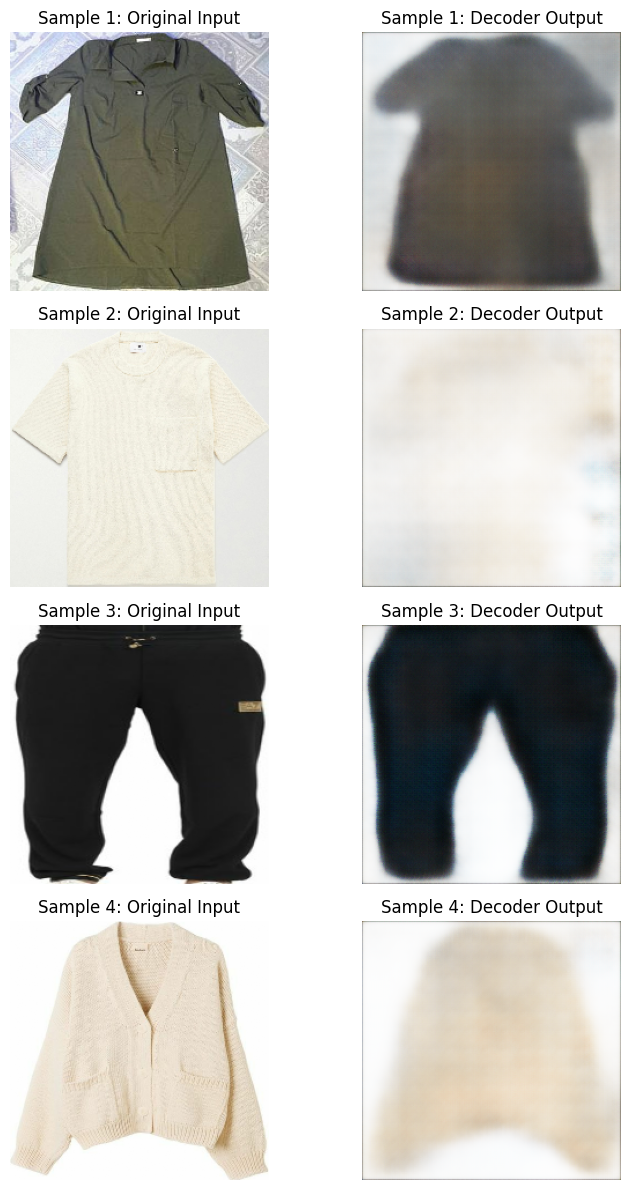

In [36]:
# 1. Grabbing the very first batch of data from your validation generator
inputs, _ = val_gen[0]

# 2. Run the batch through your model in inference mode
outputs = model(inputs, training=False)

# 3. Extract the original clean anchors and the decoder's attempts
original_anchors = inputs['anchor']
reconstructed_anchors = outputs['anc_recon']

# 4. Cast back to standard float32 array in case you are using mixed precision
original_anchors = tf.cast(original_anchors, tf.float32).numpy()
reconstructed_anchors = tf.cast(reconstructed_anchors, tf.float32).numpy()

# 5. Plot them side-by-side to visually audit the quality
num_samples = min(4, len(original_anchors))  # Inspect up to 4 items
fig, axes = plt.subplots(num_samples, 2, figsize=(8, 3 * num_samples))

for i in range(num_samples):
    # Display the ground truth image that entered the model
    axes[i, 0].imshow(original_anchors[i])
    axes[i, 0].set_title(f"Sample {i+1}: Original Input")
    axes[i, 0].axis('off')
    
    # Display what the decoder managed to recreate from the 512-D embedding
    # Clip values between 0 and 1 to prevent rendering artifacts
    axes[i, 1].imshow(np.clip(reconstructed_anchors[i], 0, 1))
    axes[i, 1].set_title(f"Sample {i+1}: Decoder Output")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()#there 

In [31]:
print(f"Total test samples: {len(test_data)} | Batch size: {BATCH_SIZE}")

Total test samples: 25 | Batch size: 32


In [35]:
from IPython.display import FileLink

# Generates a direct clickable link to your saved weights
FileLink(r'checkpoints/best_model.weights.h5')

/kaggle/working/checkpoints/best_model.weights.h5